In [1]:
import os
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

In [2]:
!pip install timm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [6]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [7]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [8]:
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=len(class_names)   # ✅ IMPORTANT
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [9]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 4])


In [10]:
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [12]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_swin.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_swin.pth"))
    return model

In [13]:
model = train_model(model, train_loader, val_loader, epochs=10)

Epoch 1/10
Train Loss: 0.8606 | Train Acc: 0.7067
Val Loss: 0.6889 | Val Acc: 0.7717 | Val F1: 0.7657
Best F1: 0.7657
--------------------------------------------------
Epoch 2/10
Train Loss: 0.6237 | Train Acc: 0.7674
Val Loss: 0.5916 | Val Acc: 0.7902 | Val F1: 0.7879
Best F1: 0.7879
--------------------------------------------------
Epoch 3/10
Train Loss: 0.5662 | Train Acc: 0.7773
Val Loss: 0.5549 | Val Acc: 0.7865 | Val F1: 0.7824
Best F1: 0.7879
--------------------------------------------------
Epoch 4/10
Train Loss: 0.5425 | Train Acc: 0.7863
Val Loss: 0.5298 | Val Acc: 0.7933 | Val F1: 0.7892
Best F1: 0.7892
--------------------------------------------------
Epoch 5/10
Train Loss: 0.5228 | Train Acc: 0.7908
Val Loss: 0.5126 | Val Acc: 0.8063 | Val F1: 0.8041
Best F1: 0.8041
--------------------------------------------------
Epoch 6/10
Train Loss: 0.5108 | Train Acc: 0.7980
Val Loss: 0.5040 | Val Acc: 0.8125 | Val F1: 0.8107
Best F1: 0.8107
-------------------------------------

In [14]:
for param in model.parameters():
    param.requires_grad = True

In [15]:
model = train_model(model, train_loader, val_loader, epochs=20)

Epoch 1/20
Train Loss: 0.8599 | Train Acc: 0.6763
Val Loss: 0.4353 | Val Acc: 0.8335 | Val F1: 0.8310
Best F1: 0.8310
--------------------------------------------------
Epoch 2/20
Train Loss: 0.4322 | Train Acc: 0.8162
Val Loss: 0.3446 | Val Acc: 0.8546 | Val F1: 0.8549
Best F1: 0.8549
--------------------------------------------------
Epoch 3/20
Train Loss: 0.4166 | Train Acc: 0.8268
Val Loss: 0.3356 | Val Acc: 0.8688 | Val F1: 0.8681
Best F1: 0.8681
--------------------------------------------------
Epoch 4/20
Train Loss: 0.3750 | Train Acc: 0.8434
Val Loss: 0.3617 | Val Acc: 0.8558 | Val F1: 0.8529
Best F1: 0.8681
--------------------------------------------------
Epoch 5/20
Train Loss: 0.3470 | Train Acc: 0.8515
Val Loss: 0.2915 | Val Acc: 0.8750 | Val F1: 0.8739
Best F1: 0.8739
--------------------------------------------------
Epoch 6/20
Train Loss: 0.3558 | Train Acc: 0.8540
Val Loss: 0.3304 | Val Acc: 0.8626 | Val F1: 0.8580
Best F1: 0.8739
-------------------------------------

In [16]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      0.99       405
             Normal       0.98      0.98      0.98       405
Pneumonia-Bacterial       0.84      0.86      0.85       405
    Pneumonia-Viral       0.86      0.82      0.84       405

           accuracy                           0.92      1620
          macro avg       0.92      0.92      0.92      1620
       weighted avg       0.92      0.92      0.92      1620



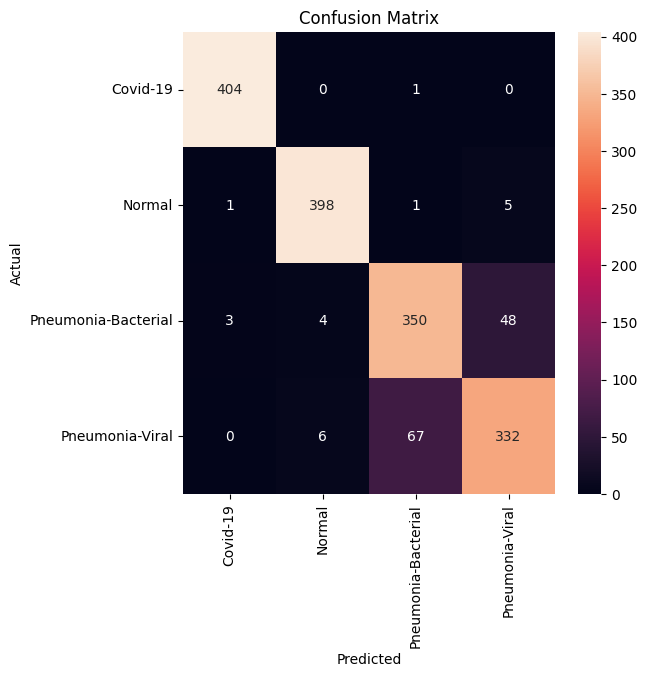

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

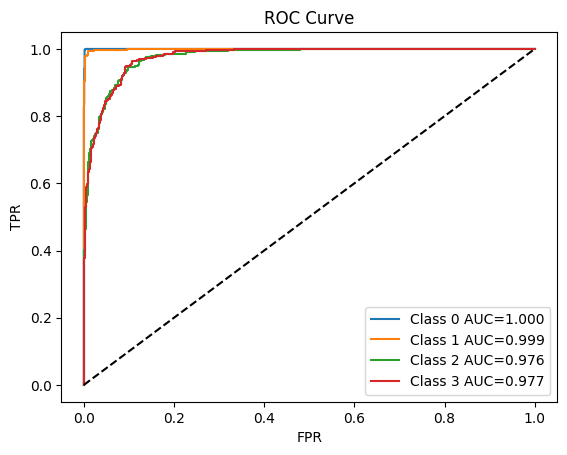

In [18]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

num_classes = all_probs.shape[1]
all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        output = self.model(x)
        self.model.zero_grad()

        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1,2))

        cam = torch.zeros(activations.shape[1:], device=x.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max()

        return cam.detach().cpu().numpy()

In [33]:
import torch
import numpy as np

def swin_explain(model, img):
    model.eval()

    with torch.no_grad():
        features = model.forward_features(img)

    # 🔥 CASE 1: If output is (B, C, H, W)
    if len(features.shape) == 4:
        heatmap = features.mean(dim=1).squeeze()  # (H, W)

    # 🔥 CASE 2: If output is (B, N, C)
    elif len(features.shape) == 3:
        tokens = features[:, 1:, :] if features.shape[1] > 1 else features
        tokens = tokens.mean(dim=2)

        size = int(np.sqrt(tokens.shape[1]))
        heatmap = tokens[:, :size*size].reshape(size, size).squeeze()

    else:
        raise ValueError("Unsupported feature shape")

    heatmap = heatmap.cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    return heatmap

In [34]:
images, labels = next(iter(test_loader))

img = images[0:1].to(device)

heatmap = swin_explain(model, img)

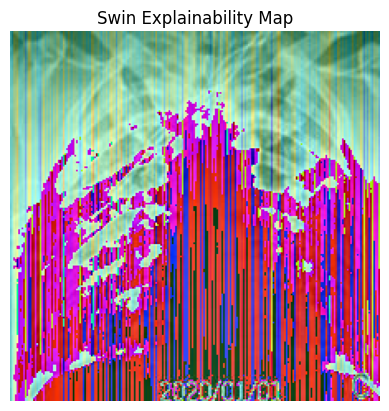

In [36]:
import cv2
import matplotlib.pyplot as plt

img_np = img.squeeze().permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

overlay = heatmap_color * 0.4 + img_np * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("Swin Explainability Map")
plt.axis('off')
plt.show()

In [37]:
import cv2

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=500, s=8, p1=0.5):
        masks = []

        for _ in range(N):
            mask = (np.random.rand(s, s) < p1).astype(np.float32)
            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)

        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            mask_tensor = torch.tensor(mask).to(self.device)
            masked = image * mask_tensor
            masked = masked.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked), dim=1)

            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i].max() * masks[i]

        saliency /= len(masks)

        return saliency

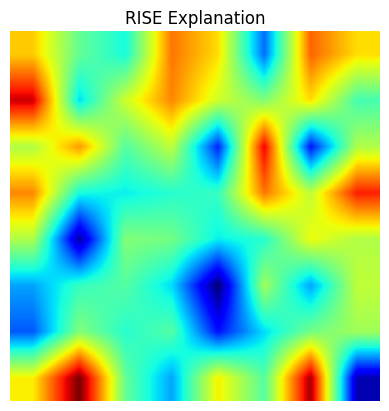

In [38]:
rise = RISE(model, (224,224), device)

images, labels = next(iter(test_loader))
img = images[0].to(device)

masks = rise.generate_masks(N=500)
saliency = rise.explain(img, masks)

plt.imshow(saliency, cmap='jet')
plt.title("RISE Explanation")
plt.axis('off')
plt.show()